In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

# 设置日志级别，减少输出
tf.get_logger().setLevel('ERROR')

In [2]:
base_dir = './dataset'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'validation')

# 超参数设置
BATCH_SIZE = 128
IMG_SIZE = (160, 160)
AUTOTUNE = tf.data.AUTOTUNE

# 数据加载与预处理
# 修正后的数据加载（移除validation_split和subset参数）
train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed=12,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    seed=12,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# 获取类名
class_names = train_dataset_raw.class_names
print("Class Names: ", class_names)

# 使用缓存和预取优化数据加载
train_dataset = train_dataset_raw.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset_raw.cache().prefetch(buffer_size=AUTOTUNE)

Found 24424 files belonging to 15 classes.
Found 3053 files belonging to 15 classes.
Class Names:  ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o']


In [3]:
# 数据增强
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.4),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
])

In [5]:
# 预训练模型（EfficientNetB0）
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNet(input_shape=IMG_SHAPE,
                                                   include_top=False,
                                                   alpha=0.25,
                                                   weights='imagenet')

# 冻结部分预训练模型层（可根据需要微调）
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False  # 仅微调最后四层

# 模型构建
model = tf.keras.Sequential([
    # data_augmentation,  # 数据增强层
    # 替换Rescaling层
    tf.keras.layers.Rescaling(1./127.5, offset=-1),  # 将像素值从[0,255]映射到[-1,1]
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    # tf.keras.layers.Dense(128, activation='relu'),  # 新增全连接层
    tf.keras.layers.Dropout(0.5),  # Dropout防止过拟合
    tf.keras.layers.Dense(len(class_names), activation='softmax')  # 输出层
])

# 显式地构建模型
model.build((None, 160, 160, 3))  # 这里的 (None, 160, 160, 3) 是输入数据的形状

# 输出模型概况
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 mobilenet_0.25_160 (Functio  (None, 5, 5, 256)        218544    
 nal)                                                            
                                                                 
 global_average_pooling2d_1   (None, 256)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 15)                3855      
                                                                 
Total params: 222,399
Trainable params: 69,903
Non-tra

In [6]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,  # 调整为更小的初始学习率
    decay_steps=10000,
    decay_rate=0.96,
    staircase=True
)

In [7]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# 使用 EarlyStopping 和 ReduceLROnPlateau
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)

# 模型训练
history = model.fit(train_dataset,
                    validation_data=validation_dataset,
                    epochs=20,
                    callbacks=[early_stopping, lr_reduction])


Epoch 1/20
191/191 [==============================] - 76s 364ms/step - loss: 0.9399 - accuracy: 0.7076 - val_loss: 0.3091 - val_accuracy: 0.9011 - lr: 0.0010
Epoch 2/20
191/191 [==============================] - 49s 260ms/step - loss: 0.3715 - accuracy: 0.8775 - val_loss: 0.1555 - val_accuracy: 0.9509 - lr: 0.0010
Epoch 3/20
191/191 [==============================] - 20s 102ms/step - loss: 0.2646 - accuracy: 0.9127 - val_loss: 0.1149 - val_accuracy: 0.9640 - lr: 0.0010
Epoch 4/20
191/191 [==============================] - 7s 39ms/step - loss: 0.2090 - accuracy: 0.9296 - val_loss: 0.0852 - val_accuracy: 0.9751 - lr: 0.0010
Epoch 5/20
191/191 [==============================] - 7s 39ms/step - loss: 0.1723 - accuracy: 0.9420 - val_loss: 0.0637 - val_accuracy: 0.9833 - lr: 0.0010
Epoch 6/20
191/191 [==============================] - 8s 40ms/step - loss: 0.1450 - accuracy: 0.9529 - val_loss: 0.0476 - val_accuracy: 0.9869 - lr: 0.0010
Epoch 7/20
191/191 [==============================] - 7s 3

In [ ]:
def representative_dataset():
    for image, _ in train_dataset.take(10000):  # 使用训练集的前10000张图片
        yield [tf.cast(image, tf.float32)]

# 转换为TFLite模型
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # 输入类型设置为 INT8
converter.inference_output_type = tf.int8  # 输出类型设置为 INT8
tflite_model_quant = converter.convert()

# 保存量化后的TFLite模型
open('./model/mnist_model_quant_int8.tflite', "wb").write(tflite_model_quant)

# 推理测试
interpreter = tf.lite.Interpreter(model_content=tflite_model_quant)
input_type = interpreter.get_input_details()[0]['dtype']
print('Input Type: ', input_type)
output_type = interpreter.get_output_details()[0]['dtype']
print('Output Type: ', output_type)

c:\Users\Garfield\miniconda3\envs\tf\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


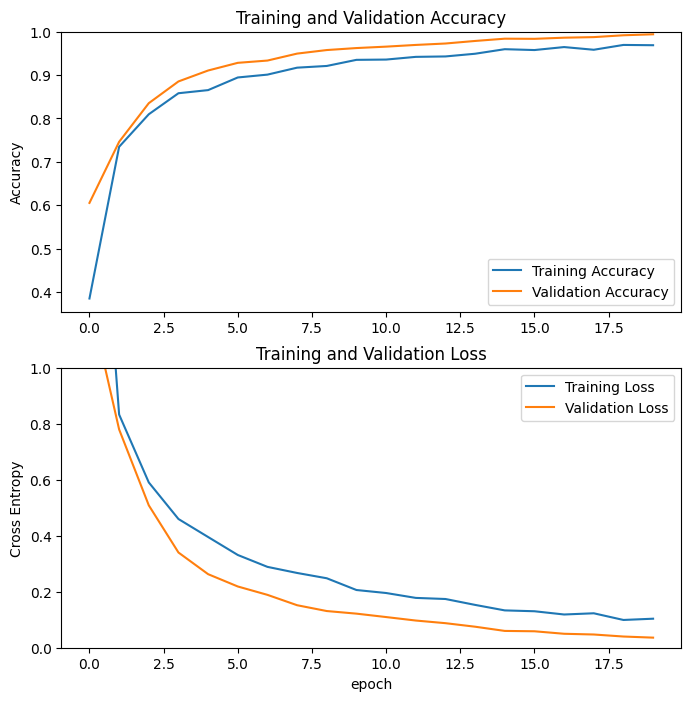

In [ ]:
# 绘制训练与验证曲线
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()), 1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0, 1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()